# DenSHAP Demo Notebook

**DenSHAP: Density-Aware Background Dataset Construction for Counterfactual Shapley Explanations**

This notebook reproduces the main experimental results on three benchmark datasets:
- **HELOC** (9,871 samples, 23 features)
- **Wine Quality** (6,497 samples, 11 features)
- **LendingClub** (sampled 20,000, 20 features)

**Methods compared:**
| Method | Background dataset |
|--------|-------------------|
| SHAP_TRAIN | Random from all training data |
| SHAP_D_LAB | Random from opposite-label data |
| SHAP_D_PRED | Random from opposite-predicted data |
| CF_SHAP | IQR-normalized KNN (distance only) |
| **DenSHAP** | **LOF-weighted KNN (distance + density)** |

> **Prerequisites:** Place `heloc.csv`, `lendingclub.csv`, `wine.csv` in `data/` folder.


## 0. Install Dependencies

In [1]:
# Install required packages (run once)
# !pip install shap xgboost scikit-learn pandas numpy optuna dice-ml


## 1. Setup

In [2]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# Add DenSHAP source to path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from data_loader import load_dataset
from cfshap_baseline import CFSHAPEvaluator
from denshap import DenSHAPPipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

print("✅ All imports successful")


✅ All imports successful


## 2. Quick Demo — Synthetic Data

A fast end-to-end demo using synthetic data to verify the pipeline before running real datasets.


In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

np.random.seed(42)

# Synthetic data with multiple clusters (mimics Hard Case distribution)
X, y = make_classification(
    n_samples=600, n_features=10, n_informative=5,
    n_clusters_per_class=3, weights=[0.65, 0.35], random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
feature_names = [f'feature_{i}' for i in range(10)]

model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"Model accuracy: {model.score(X_test, y_test):.3f}")

X_eval = X_test[:20]
y_eval = model.predict(X_eval)


Model accuracy: 0.883


In [4]:
# Initialize DenSHAP (LOF estimator fitted here)
denshap_pipe = DenSHAPPipeline(
    model=model,
    X_train=X_train,
    y_train=y_train,
    feature_names=feature_names,
    k_total=50,
    k_lof=15,
    top_k_list=[1, 2, 3, 5],
    random_state=42
)

# Initialize CF-SHAP baselines (shares DenSHAP's LOF estimator for BDS comparison)
cfshap_eval = CFSHAPEvaluator(
    model=model,
    X_train=X_train,
    y_train=y_train,
    k_neighbors=50,
    top_k_list=[1, 2, 3, 5],
    random_state=42,
    lof_estimator=denshap_pipe.lof_est
)

# Run evaluation
print("Running CF-SHAP baselines...")
cfshap_results = cfshap_eval.evaluate(X_eval, y_eval, verbose=False)

print("Running DenSHAP...")
denshap_results = denshap_pipe.evaluate(X_eval, y_eval, verbose=False)

# Summary
cfshap_summary = cfshap_eval.summary(cfshap_results)
denshap_summary = denshap_pipe.summary(denshap_results)

print("\n=== CF-SHAP Baselines ===")
display(cfshap_summary.round(4))

print("\n=== DenSHAP (by LOF group) ===")
display(denshap_summary.round(4))


[Init] Fitting LOF estimator...
         Q25: 1.0041 | Q75: 1.1095
[Init] Done. (DiCE-free — LOF-weighted KNN only)

Running CF-SHAP baselines...
Running DenSHAP...

=== CF-SHAP Baselines ===


,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,BDS,KNN_success_rate
Method,,,,,,,
SHAP_TRAIN,7.7516,6.0559,3.9876,2.9361,1.0447,0.9414,NaN
SHAP_D_LAB,8.5909,4.3440,3.2796,3.7495,1.0819,0.9319,NaN
SHAP_D_PRED,7.2617,4.3004,4.1252,3.7783,1.0572,0.9358,NaN
CF_SHAP,6.8095,4.3117,3.6885,3.3043,0.9427,0.9740,1.0



=== DenSHAP (by LOF group) ===


,N,α_mean,LOF_mean,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,Validity,KNN_success,BDS
Group,,,,,,,,,,,
Total,20,0.5048,1.0681,6.8048,4.3440,4.1441,3.7737,1.0057,1.0,1.0,0.9569
Easy,9,0.0491,0.9941,6.8341,4.9463,4.1780,2.6593,1.0155,1.0,1.0,0.9570
Medium,3,0.5977,1.0671,10.0000,1.2577,1.5076,2.4606,1.0202,1.0,1.0,0.9541
Hard,8,0.9825,1.1518,5.5737,4.8237,5.0948,5.5199,0.9892,1.0,1.0,0.9579


## 3. Real Dataset Experiments

Run the full comparison on HELOC, Wine Quality, and LendingClub.

> **Note:** Set `EVAL_N` to control evaluation speed.  
> `EVAL_N = 50` → fast preview | `EVAL_N = 999999` → full test set


In [5]:
# ── Configuration ────────────────────────────
DATASETS = ['wine', 'heloc', 'lendingclub']
# EVAL_N: number of evaluation samples per dataset
#   50      → quick preview (~1 min per dataset)
#   200     → moderate (~10 min per dataset)
#   999999  → full test set (recommended for paper)
#             Wine ~1300 / HELOC ~1975 / LendingClub ~4000
EVAL_N = 999999
TOP_K    = [1, 2, 3, 5]
K_TOTAL  = 100
K_LOF    = 20
LC_SAMPLE = 20000    # LendingClub training sample size

RESULTS = {}         # Store results for all datasets


In [6]:
import time
from sklearn.metrics import roc_auc_score

def run_dataset(dataset_name, eval_n=50):
    print(f"\n{'='*55}")
    print(f"  Dataset: {dataset_name.upper()}")
    print(f"{'='*55}")

    # Load data
    if dataset_name == 'lendingclub':
        from data_loader import load_lendingclub
        X_train, X_test, y_train, y_test, feat = load_lendingclub(
            'data/lendingclub.csv', sample_n=LC_SAMPLE
        )
    else:
        X_train, X_test, y_train, y_test, feat = load_dataset(dataset_name)

    # Train model
    print("\n[Model] Training XGBoost...")
    model = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"  Accuracy: {(y_pred==y_test).mean():.3f} | AUC: {auc:.3f}")

    # Evaluation sample selection (stratified)
    np.random.seed(42)
    n = min(eval_n, len(X_test))
    idx_0 = np.where(model.predict(X_test) == 0)[0]
    idx_1 = np.where(model.predict(X_test) == 1)[0]
    n0 = min(n//2, len(idx_0))
    n1 = min(n-n0, len(idx_1))
    sel = np.concatenate([
        np.random.choice(idx_0, n0, replace=False),
        np.random.choice(idx_1, n1, replace=False)
    ])
    np.random.shuffle(sel)
    X_eval = X_test[sel]
    y_eval = model.predict(X_eval)
    print(f"  Evaluation: {len(X_eval)} samples (class 0: {n0}, class 1: {n1})")

    # DenSHAP
    print("\n[DenSHAP] Initializing...")
    denshap_pipe = DenSHAPPipeline(
        model=model, X_train=X_train, y_train=y_train,
        feature_names=feat, k_total=K_TOTAL, k_lof=K_LOF,
        top_k_list=TOP_K, random_state=42
    )

    # CF-SHAP Baselines
    print("[CF-SHAP] Running baselines...")
    t0 = time.time()
    cfshap_eval = CFSHAPEvaluator(
        model=model, X_train=X_train, y_train=y_train,
        k_neighbors=K_TOTAL, top_k_list=TOP_K,
        random_state=42, lof_estimator=denshap_pipe.lof_est
    )
    cfshap_res = cfshap_eval.evaluate(X_eval, y_eval, verbose=False)
    cfshap_sum = cfshap_eval.summary(cfshap_res)
    t_cf = time.time() - t0
    print(f"  Done in {t_cf:.1f}s")

    # DenSHAP Evaluation
    print("[DenSHAP] Running evaluation...")
    t0 = time.time()
    denshap_res = denshap_pipe.evaluate(X_eval, y_eval, verbose=False)
    denshap_sum = denshap_pipe.summary(denshap_res)
    t_ds = time.time() - t0
    print(f"  Done in {t_ds:.1f}s")

    return {
        'cfshap_res': cfshap_res, 'cfshap_sum': cfshap_sum,
        'denshap_res': denshap_res, 'denshap_sum': denshap_sum,
        'model': model, 'feat': feat,
        'X_eval': X_eval, 'y_eval': y_eval
    }


In [7]:
# Run all datasets (skip if data/ files not available)
for ds in DATASETS:
    try:
        RESULTS[ds] = run_dataset(ds, eval_n=EVAL_N)
        print(f"\n✅ {ds.upper()} complete")
    except FileNotFoundError:
        print(f"⚠️  {ds}: data file not found in data/ — skipping")
    except Exception as e:
        print(f"❌ {ds}: {e}")



  Dataset: WINE
[Wine Quality] loading...
  Columns: ['\ufefffixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'target']
  Features used (11 features): ['\ufefffixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
  Total samples: 6497
  Train: (5197, 11) | Test: (1300, 11)
  Label distribution (train): {0: 4176, 1: 1021}
  Minority class ratio: 0.196

[Model] Training XGBoost...
  Accuracy: 0.855 | AUC: 0.874
  Evaluation: 812 samples (class 0: 650, class 1: 162)

[DenSHAP] Initializing...
[Init] Fitting LOF estimator...
         Q25: 0.9966 | Q75: 1.0648
[Init] Done. (DiCE-free — LOF-weighted KNN only)

[CF-SHAP] Running baselines...
  Done in 417.6s
[DenSHAP] Running evaluation...
  Done in 251.5s

✅ WINE complete

  Dataset: HELOC
[HELOC]

## 4. Results Tables

### 4-1. Overall Comparison (paper Table format)


In [8]:
for ds, res in RESULTS.items():
    print(f"\n{'─'*55}")
    print(f"  {ds.upper()} — Method Comparison")
    print(f"{'─'*55}")

    cf  = res['cfshap_sum']
    ds_ = res['denshap_sum']

    rows = []
    for m in ['SHAP_TRAIN','SHAP_D_LAB','SHAP_D_PRED','CF_SHAP']:
        row = {'Method': m}
        for k in TOP_K:
            if f'CA_top{k}' in cf.columns:
                row[f'CA_top{k}'] = cf.loc[m, f'CA_top{k}']
        if 'Plausibility' in cf.columns:
            row['Plausibility'] = cf.loc[m, 'Plausibility']
        if 'BDS' in cf.columns:
            row['BDS'] = cf.loc[m, 'BDS']
        rows.append(row)

    # DenSHAP overall (Total group)
    row = {'Method': 'DenSHAP (ours)'}
    for k in TOP_K:
        if f'CA_top{k}' in ds_.columns and 'Total' in ds_.index:
            row[f'CA_top{k}'] = ds_.loc['Total', f'CA_top{k}']
    if 'Plausibility' in ds_.columns and 'Total' in ds_.index:
        row['Plausibility'] = ds_.loc['Total', 'Plausibility']
    if 'BDS' in ds_.columns and 'Total' in ds_.index:
        row['BDS'] = ds_.loc['Total', 'BDS']
    rows.append(row)

    table = pd.DataFrame(rows).set_index('Method')
    display(table.round(4))



───────────────────────────────────────────────────────
  WINE — Method Comparison
───────────────────────────────────────────────────────


,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,BDS
Method,,,,,,
SHAP_TRAIN,9.6110,9.3522,9.1485,8.9163,0.6724,0.9592
SHAP_D_LAB,9.4822,9.2462,9.0353,8.7360,0.6269,0.9616
SHAP_D_PRED,9.4942,9.2825,9.0614,8.6955,0.6188,0.9619
CF_SHAP,9.3394,8.9855,8.6760,8.4479,0.5470,0.9723
DenSHAP (ours),9.4240,9.1305,8.9215,8.6123,0.5497,0.9763



───────────────────────────────────────────────────────
  HELOC — Method Comparison
───────────────────────────────────────────────────────


,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,BDS
Method,,,,,,
SHAP_TRAIN,9.4309,9.1561,8.9406,8.7752,1.6798,0.9433
SHAP_D_LAB,9.3014,8.9187,8.6305,8.5636,1.6652,0.9442
SHAP_D_PRED,9.2480,8.8829,8.5784,8.5057,1.6520,0.9438
CF_SHAP,9.1228,8.7591,8.6249,8.5927,1.5058,0.9648
DenSHAP (ours),9.1350,8.7246,8.5447,8.5020,1.4357,0.9726



───────────────────────────────────────────────────────
  LENDINGCLUB — Method Comparison
───────────────────────────────────────────────────────


,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,BDS
Method,,,,,,
SHAP_TRAIN,9.3797,9.1215,8.9631,8.8211,1.1741,0.9661
SHAP_D_LAB,9.2512,8.9129,8.7285,8.5182,1.1704,0.9668
SHAP_D_PRED,9.1533,8.8251,8.6318,8.4204,1.1731,0.9663
CF_SHAP,9.0548,8.7161,8.5462,8.4196,1.0423,0.9738
DenSHAP (ours),9.0460,8.6352,8.4470,8.3227,1.0036,0.9767


### 4-2. DenSHAP by LOF Difficulty Group

In [9]:
for ds, res in RESULTS.items():
    print(f"\n{'─'*55}")
    print(f"  {ds.upper()} — DenSHAP by LOF Group")
    print(f"{'─'*55}")
    display(res['denshap_sum'].round(4))



───────────────────────────────────────────────────────
  WINE — DenSHAP by LOF Group
───────────────────────────────────────────────────────


,N,α_mean,LOF_mean,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,Validity,KNN_success,BDS
Group,,,,,,,,,,,
Total,812,0.4760,1.0667,9.4240,9.1305,8.9215,8.6123,0.5497,1.0,1.0,0.9763
Easy,370,0.0859,0.9970,9.4613,9.1689,9.0025,8.6670,0.5533,1.0,1.0,0.9761
Medium,144,0.4866,1.0298,9.3930,9.0107,8.7045,8.4169,0.5368,1.0,1.0,0.9771
Hard,298,0.9552,1.1712,9.3928,9.1406,8.9257,8.6388,0.5515,1.0,1.0,0.9763



───────────────────────────────────────────────────────
  HELOC — DenSHAP by LOF Group
───────────────────────────────────────────────────────


,N,α_mean,LOF_mean,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,Validity,KNN_success,BDS
Group,,,,,,,,,,,
Total,1975,0.4580,1.0745,9.1350,8.7246,8.5447,8.5020,1.4357,1.0,1.0,0.9726
Easy,928,0.0722,1.0048,9.2511,8.9062,8.6356,8.5435,1.3657,1.0,1.0,0.9787
Medium,339,0.4822,1.0527,9.0532,8.6116,8.4190,8.3700,1.4558,1.0,1.0,0.9720
Hard,708,0.9521,1.1762,9.0220,8.5407,8.4858,8.5108,1.5180,1.0,1.0,0.9650



───────────────────────────────────────────────────────
  LENDINGCLUB — DenSHAP by LOF Group
───────────────────────────────────────────────────────


,N,α_mean,LOF_mean,CA_top1,CA_top2,CA_top3,CA_top5,Plausibility,Validity,KNN_success,BDS
Group,,,,,,,,,,,
Total,4000,0.5002,1.0508,9.0460,8.6352,8.4470,8.3227,1.0036,1.0,1.0,0.9767
Easy,1682,0.0840,0.9980,9.1505,8.7213,8.5542,8.4649,0.9876,1.0,1.0,0.9784
Medium,723,0.4914,1.0295,9.0719,8.7693,8.4863,8.4043,1.0011,1.0,1.0,0.9780
Hard,1595,0.9431,1.1162,8.9239,8.4836,8.3162,8.1357,1.0216,1.0,1.0,0.9744


### 4-3. BDS by LOF Group (Core Paper Claim)

In [10]:
print("BDS Hard Group: DenSHAP vs CF-SHAP")
print("(Higher BDS = background from denser regions)\n")

bds_rows = []
for ds, res in RESULTS.items():
    dr = res['denshap_res']
    cr = res['cfshap_res']
    for group in ['Easy', 'Medium', 'Hard']:
        df_g = dr[dr['difficulty_group'] == group]
        if len(df_g) == 0:
            continue
        ds_bds = df_g['DenSHAP_bds'].mean() if 'DenSHAP_bds' in df_g.columns else np.nan
        cf_bds = cr.loc[df_g.index, 'CF_SHAP_bds'].mean() if 'CF_SHAP_bds' in cr.columns else np.nan
        delta  = (ds_bds - cf_bds) / cf_bds * 100 if cf_bds > 0 else np.nan
        bds_rows.append({
            'Dataset': ds.upper(), 'Group': group,
            'CF_SHAP_BDS': round(cf_bds, 4),
            'DenSHAP_BDS': round(ds_bds, 4),
            'Δ (%)': f"{'↑' if delta>0 else '↓'}{abs(delta):.1f}%" if not np.isnan(delta) else 'N/A'
        })

bds_df = pd.DataFrame(bds_rows)
display(bds_df[bds_df['Group'] == 'Hard'].set_index(['Dataset','Group']))


BDS Hard Group: DenSHAP vs CF-SHAP
(Higher BDS = background from denser regions)



,,CF_SHAP_BDS,DenSHAP_BDS,Δ (%)
Dataset,Group,,,
WINE,Hard,0.9644,0.9763,↑1.2%
HELOC,Hard,0.9386,0.9650,↑2.8%
LENDINGCLUB,Hard,0.9652,0.9744,↑1.0%


## 5. Visualizations

### 5-1. CA Comparison by Method

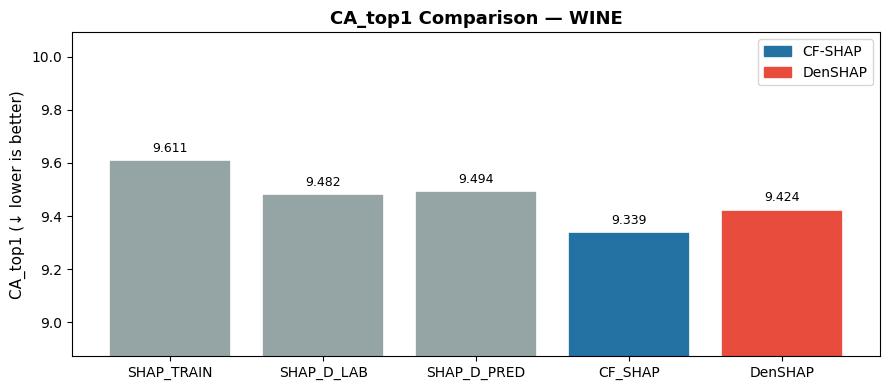

In [11]:
if RESULTS:
    ds = list(RESULTS.keys())[0]
    res = RESULTS[ds]
    cf  = res['cfshap_sum']
    dr  = res['denshap_sum']

    methods = ['SHAP_TRAIN', 'SHAP_D_LAB', 'SHAP_D_PRED', 'CF_SHAP', 'DenSHAP']
    ca_vals = []
    for m in ['SHAP_TRAIN','SHAP_D_LAB','SHAP_D_PRED','CF_SHAP']:
        ca_vals.append(cf.loc[m, 'CA_top1'] if 'CA_top1' in cf.columns else np.nan)
    if 'Total' in dr.index and 'CA_top1' in dr.columns:
        ca_vals.append(dr.loc['Total', 'CA_top1'])
    else:
        ca_vals.append(np.nan)

    colors = ['#95a5a6','#95a5a6','#95a5a6','#2471a3','#e74c3c']
    fig, ax = plt.subplots(figsize=(9,4))
    bars = ax.bar(methods, ca_vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_ylabel('CA_top1 (↓ lower is better)', fontsize=11)
    ax.set_title(f'CA_top1 Comparison — {ds.upper()}', fontsize=13, fontweight='bold')
    ax.set_ylim(min(ca_vals)*0.95 if ca_vals else 0, max(ca_vals)*1.05 if ca_vals else 10)
    for bar, val in zip(bars, ca_vals):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    patches = [mpatches.Patch(color='#2471a3', label='CF-SHAP'),
               mpatches.Patch(color='#e74c3c', label='DenSHAP')]
    ax.legend(handles=patches)
    plt.tight_layout()
    plt.show()


### 5-2. BDS by LOF Group Across Datasets

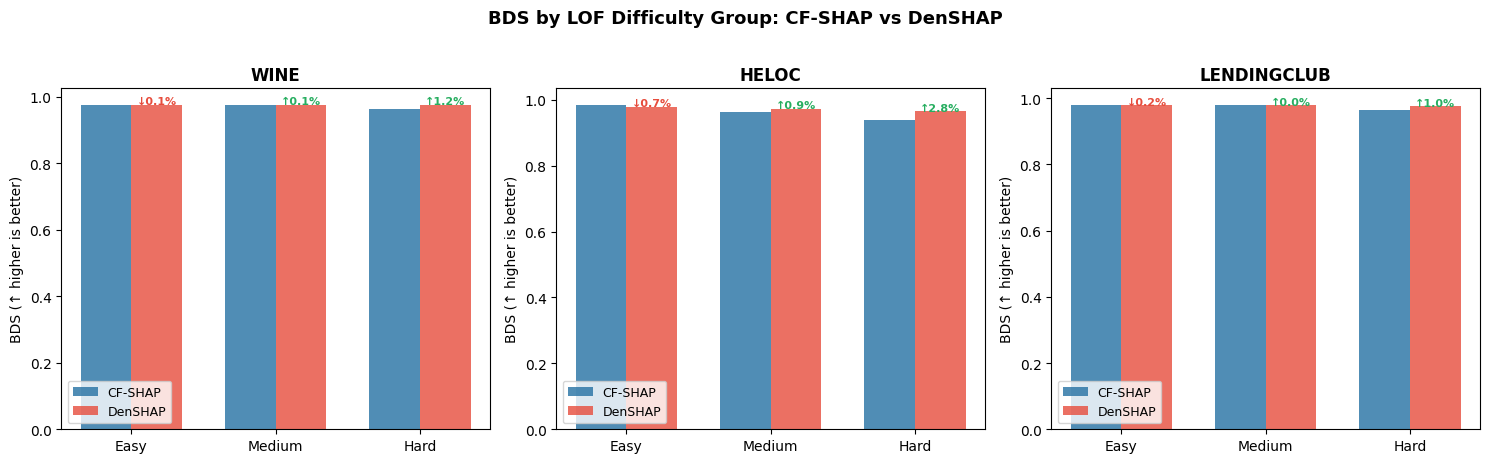

In [12]:
if RESULTS:
    fig, axes = plt.subplots(1, len(RESULTS), figsize=(5*len(RESULTS), 4.5), sharey=False)
    if len(RESULTS) == 1: axes = [axes]

    for ax, (ds, res) in zip(axes, RESULTS.items()):
        dr = res['denshap_res']
        cr = res['cfshap_res']
        groups = ['Easy', 'Medium', 'Hard']
        cf_bds, ds_bds = [], []
        for g in groups:
            df_g = dr[dr['difficulty_group'] == g]
            if len(df_g) == 0:
                cf_bds.append(np.nan); ds_bds.append(np.nan); continue
            ds_bds.append(df_g['DenSHAP_bds'].mean() if 'DenSHAP_bds' in df_g.columns else np.nan)
            cf_bds.append(cr.loc[df_g.index, 'CF_SHAP_bds'].mean() if 'CF_SHAP_bds' in cr.columns else np.nan)

        x = np.arange(len(groups))
        w = 0.35
        b1 = ax.bar(x-w/2, cf_bds, w, label='CF-SHAP', color='#2471a3', alpha=0.8)
        b2 = ax.bar(x+w/2, ds_bds, w, label='DenSHAP', color='#e74c3c', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(groups)
        ax.set_title(f'{ds.upper()}', fontsize=12, fontweight='bold')
        ax.set_ylabel('BDS (↑ higher is better)')
        ax.legend(fontsize=9)

        # Annotate Hard group delta
        for i, (c, d) in enumerate(zip(cf_bds, ds_bds)):
            if not (np.isnan(c) or np.isnan(d)): 
                delta = (d-c)/c*100
                color = '#27ae60' if delta > 0 else '#e74c3c'
                ax.text(i+w/2, d+0.002, f'{"↑" if delta>0 else "↓"}{abs(delta):.1f}%',
                        ha='center', fontsize=8, color=color, fontweight='bold')

    plt.suptitle('BDS by LOF Difficulty Group: CF-SHAP vs DenSHAP',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


### 5-3. LOF Distribution (Difficulty Group Breakdown)

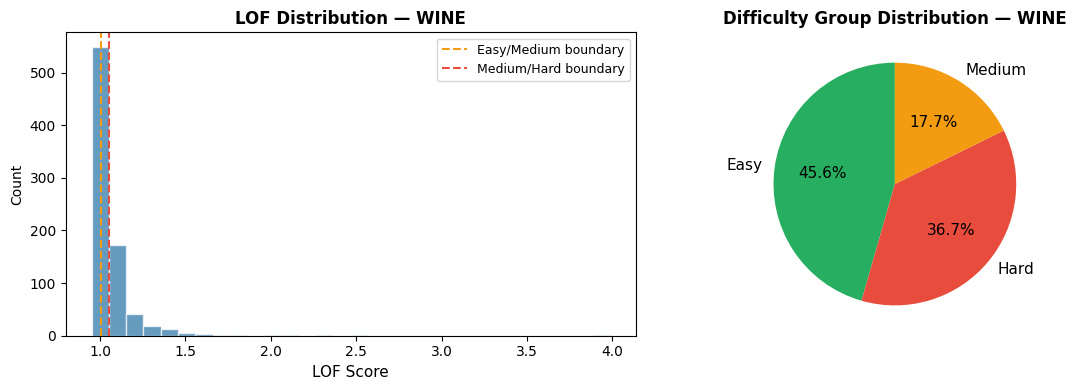


Group counts:


,count
difficulty_group,
Easy,370
Hard,298
Medium,144


In [13]:
if RESULTS:
    ds = list(RESULTS.keys())[0]
    dr = RESULTS[ds]['denshap_res']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # LOF histogram
    ax = axes[0]
    ax.hist(dr['lof_score'], bins=30, color='#2471a3', alpha=0.7, edgecolor='white')
    ax.axvline(dr['lof_score'].quantile(0.33), color='#f39c12', linestyle='--', label='Easy/Medium boundary')
    ax.axvline(dr['lof_score'].quantile(0.67), color='#e74c3c', linestyle='--', label='Medium/Hard boundary')
    ax.set_xlabel('LOF Score', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_title(f'LOF Distribution — {ds.upper()}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    # Group pie chart
    ax = axes[1]
    counts = dr['difficulty_group'].value_counts()
    colors_pie = {'Easy':'#27ae60','Medium':'#f39c12','Hard':'#e74c3c'}
    pie_colors = [colors_pie.get(g,'#95a5a6') for g in counts.index]
    ax.pie(counts.values, labels=counts.index, colors=pie_colors,
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize':11})
    ax.set_title(f'Difficulty Group Distribution — {ds.upper()}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\nGroup counts:")
    display(dr['difficulty_group'].value_counts().to_frame('count'))


## 6. Single Instance Explanation

Explain a single instance using DenSHAP and compare with CF-SHAP.


In [14]:
if RESULTS:
    ds   = list(RESULTS.keys())[0]
    res  = RESULTS[ds]
    pipe = DenSHAPPipeline(
        model=res['model'], X_train=res['X_eval'],
        y_train=res['y_eval'], feature_names=res['feat'],
        k_total=20, k_lof=10, top_k_list=[1,2,3,5], random_state=42
    )

    x0     = res['X_eval'][0]
    label0 = int(res['y_eval'][0])
    row    = pipe._run_single(x0, label0)

    print(f"Instance label (model prediction): {label0}")
    print(f"LOF score : {row['lof_score']:.4f}")
    print(f"α(x)      : {row['alpha']:.4f}")
    print(f"Group     : {row['difficulty_group']}")
    print(f"Validity  : {row['DenSHAP_validity']:.3f}")
    print(f"BDS       : {row['DenSHAP_bds']:.4f}")
    print()
    for k in [1,2,3,5]:
        ca = row.get(f'DenSHAP_CA_top{k}', 'N/A')
        print(f"CA_top{k}  : {ca:.4f}" if isinstance(ca, float) else f"CA_top{k}  : {ca}")


[Init] Fitting LOF estimator...
         Q25: 0.9950 | Q75: 1.0905
[Init] Done. (DiCE-free — LOF-weighted KNN only)

Instance label (model prediction): 0
LOF score : 1.0133
α(x)      : 0.1917
Group     : Easy
Validity  : 1.000
BDS       : 0.9747

CA_top1  : 10.0000
CA_top2  : 10.0000
CA_top3  : 10.0000
CA_top5  : 10.0000


## 7. Reproducibility Notes

All experiments use:
- **Random seed:** 42 (fixed across all modules)
- **Model:** XGBoost with Optuna hyperparameter tuning (30 trials, 3-fold stratified CV, AUC objective)
- **Saved models:** Re-running `run_experiment.py` loads saved `.joblib` models from `results/` — delete to retune
- **Distance metric:** IQR-normalized Euclidean distance throughout (removes feature scale differences)
- **Opposite-label filter:** Model predictions (not training labels) — ensures Validity ≈ 100%

```bash
# To reproduce from scratch (deletes saved models)
rm results/*.joblib
python run_experiment.py
```


In [15]:
# ── Save All Results to results/ ──────────────────────────────
import os
os.makedirs('results', exist_ok=True)

for ds, res in RESULTS.items():

    # 1. Per-sample CF-SHAP results
    res['cfshap_res'].to_csv(f'results/{ds}_cfshap.csv', index=False)

    # 2. Per-sample DenSHAP results
    res['denshap_res'].to_csv(f'results/{ds}_denshap.csv', index=False)

    # 3. Method-level summary (paper Table format)
    cf  = res['cfshap_sum']
    ds_ = res['denshap_sum']

    rows = []
    for m in ['SHAP_TRAIN', 'SHAP_D_LAB', 'SHAP_D_PRED', 'CF_SHAP']:
        row = {'Method': m}
        for k in TOP_K:
            if f'CA_top{k}' in cf.columns:
                row[f'CA_top{k}'] = cf.loc[m, f'CA_top{k}']
        if 'Plausibility' in cf.columns:
            row['Plausibility'] = cf.loc[m, 'Plausibility']
        if 'BDS' in cf.columns:
            row['BDS'] = cf.loc[m, 'BDS']
        rows.append(row)

    # DenSHAP overall
    row = {'Method': 'DenSHAP (ours)'}
    if 'Total' in ds_.index:
        for k in TOP_K:
            if f'CA_top{k}' in ds_.columns:
                row[f'CA_top{k}'] = ds_.loc['Total', f'CA_top{k}']
        if 'Plausibility' in ds_.columns:
            row['Plausibility'] = ds_.loc['Total', 'Plausibility']
        if 'BDS' in ds_.columns:
            row['BDS'] = ds_.loc['Total', 'BDS']
    rows.append(row)

    summary_df = pd.DataFrame(rows).set_index('Method')
    summary_df.to_csv(f'results/{ds}_summary.csv')

    # 4. DenSHAP LOF group breakdown
    ds_.to_csv(f'results/{ds}_group.csv')

    # 5. BDS comparison by group
    bds_rows = []
    dr = res['denshap_res']
    cr = res['cfshap_res']
    for group in ['Easy', 'Medium', 'Hard']:
        df_g = dr[dr['difficulty_group'] == group]
        if len(df_g) == 0:
            continue
        ds_bds = df_g['DenSHAP_bds'].mean() if 'DenSHAP_bds' in df_g.columns else np.nan
        cf_bds = cr.loc[df_g.index, 'CF_SHAP_bds'].mean() if 'CF_SHAP_bds' in cr.columns else np.nan
        delta  = (ds_bds - cf_bds) / cf_bds * 100 if cf_bds > 0 else np.nan
        bds_rows.append({
            'Dataset': ds.upper(), 'Group': group,
            'N': len(df_g),
            'CF_SHAP_BDS': round(cf_bds, 4),
            'DenSHAP_BDS': round(ds_bds, 4),
            'Delta_pct': round(delta, 2) if not np.isnan(delta) else np.nan,
            'Direction': f"{'↑' if delta > 0 else '↓'}{abs(delta):.1f}%" if not np.isnan(delta) else 'N/A'
        })

    bds_df = pd.DataFrame(bds_rows)
    bds_df.to_csv(f'results/{ds}_bds_by_group.csv', index=False)

    print(f"✅ {ds.upper()} results saved to results/")

print("\nAll results saved:")
for f in sorted(os.listdir('results')):
    if f.endswith('.csv'):
        print(f"  results/{f}")

✅ WINE results saved to results/
✅ HELOC results saved to results/
✅ LENDINGCLUB results saved to results/

All results saved:
  results/heloc_bds_by_group.csv
  results/heloc_cfshap.csv
  results/heloc_denshap.csv
  results/heloc_group.csv
  results/heloc_summary.csv
  results/lendingclub_bds_by_group.csv
  results/lendingclub_cfshap.csv
  results/lendingclub_denshap.csv
  results/lendingclub_group.csv
  results/lendingclub_summary.csv
  results/wine_bds_by_group.csv
  results/wine_cfshap.csv
  results/wine_denshap.csv
  results/wine_group.csv
  results/wine_summary.csv
